In [141]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

%config InlineBackend.figure_format = 'svg'

In [142]:
def freq_plot():
    plt.xscale("log")
    plt.xticks(
        [60, 100, 230, 500, 1100, 2400, 5400, 12000],
        ["60", "100", "230", "500", "1.1k", "2.4k", "5.4k", "12k"],
    )

In [143]:


# Combined magnitude response in dB
def calculate_eq_response(bands, sample_rate, num_points, freqs):
    total_response_db = np.zeros(num_points)

    for band in bands:
        f0 = band["freq"]
        gain = band["gain"]
        Q = band["Q"]

        if gain == 0.0:
            continue

        # Peaking EQ filter coefficients (Audio EQ Cookbook - Robert Bristow-Johnson)
        A = 10 ** (gain / 40.0)
        w0 = 2 * np.pi * f0 / sample_rate
        alpha = np.sin(w0) / (2 * Q)

        b0 = 1 + alpha * A
        b1 = -2 * np.cos(w0)
        b2 = 1 - alpha * A
        a0 = 1 + alpha / A
        a1 = -2 * np.cos(w0)
        a2 = 1 - alpha / A

        # Normalize
        b0 /= a0
        b1 /= a0
        b2 /= a0
        a1 /= a0
        a2 /= a0

        # Evaluate H(e^jw) at each frequency
        w = 2 * np.pi * freqs / sample_rate
        ejw = np.exp(1j * w)
        ejw2 = np.exp(2j * w)

        H = (b0 + b1 * ejw**-1 + b2 * ejw2**-1) / (1 + a1 * ejw**-1 + a2 * ejw2**-1)
        total_response_db += 20 * np.log10(np.abs(H))
    return total_response_db


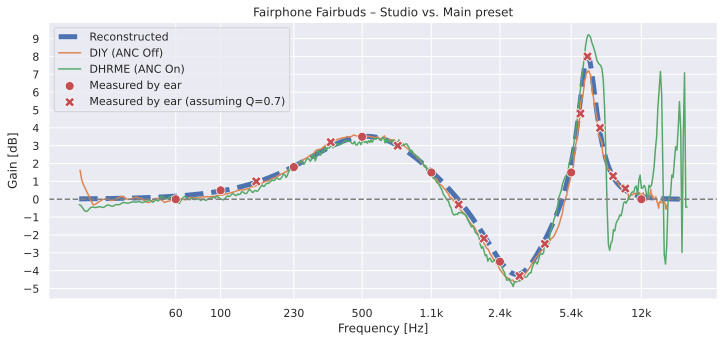

In [144]:
bands = [
    {"freq": 550, "gain": 3.7, "Q": 0.50},
    {"freq": 2900, "gain": -5, "Q": 1},
    {"freq": 6500, "gain": 9, "Q": 3},
]

sample_rate = 44100  # Hz

num_points = 695  # Match the number of samples in AutoEq
freqs = np.logspace(np.log10(20), np.log10(20000), num_points)

total_response_db = calculate_eq_response(bands, sample_rate, num_points, freqs)

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=freqs,
    y=total_response_db,
    label="Reconstructed",
    linestyle="--",
    linewidth=5,
)

df_diy = pd.read_csv("../signatures/diy.csv")
sns.lineplot(data=df_diy, x="frequency", y="raw", label="DIY (ANC Off)")

df_dhrme = pd.read_csv("../signatures/dhrme.csv")
sns.lineplot(data=df_dhrme, x="frequency", y="raw", label="DHRME (ANC On)")

colors = sns.color_palette()
# Add manually measured points
sns.scatterplot(
    x=[60, 100, 230, 500, 1100, 2400, 5400, 12000],
    y=[0, 0.5, 1.8, 3.5, 1.5, -3.5, 1.5, 0],
    label="Measured by ear",
    marker="o",
    color=colors[3],
    s=80,
    zorder=100,
)
# Add manually measured points
ax = sns.scatterplot(
    x=[150, 350, 750, 1500, 2000, 3000, 4000, 6000, 6500, 7500, 8700, 10000],
    y=[1, 3.2, 3, -0.3, -2.2, -4.3, -2.5, 4.8, 8, 4, 1.3, 0.6],
    label="Measured by ear (assuming Q=0.7)",
    marker="X",
    color=colors[3],
    s=100,
    zorder=100,
)

plt.xscale("log")
plt.yticks(np.arange(-5, 10, 1))
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Gain [dB]")
plt.title("Fairphone Fairbuds – Studio vs. Main preset")
freq_plot()
plt.show()

In [145]:
# Save as csv
output_df = pd.DataFrame({"frequency": freqs, "raw": total_response_db})
output_df = output_df.round(2)
output_df.to_csv("../signatures/reconstructed.csv", index=False)

/tmp/ipykernel_39203/3508514490.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_target = pd.read_csv("../AutoEq/targets/JM-1 with Harman filters.csv", sep=", ").rename(


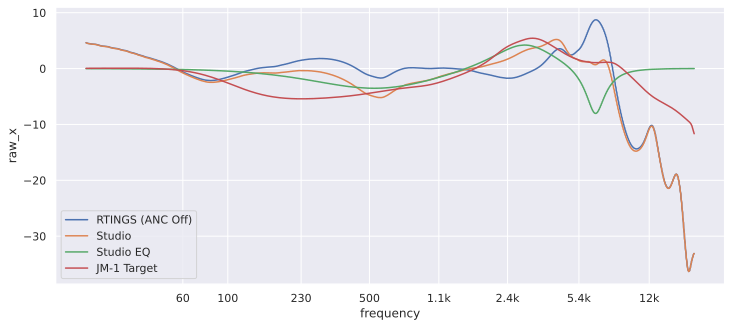

In [146]:
df = pd.read_csv("../measurements/RTINGS (main eq, ANC Off).csv")
df = pd.merge(df, output_df, on="frequency", how="outer").interpolate()
df["studio_eq"] = -df["raw_y"]
df["studio"] = df["raw_x"] + df["studio_eq"]

df_target = pd.read_csv("../AutoEq/targets/JM-1 with Harman filters.csv", sep=", ").rename(
    columns={"* Freq(Hz)": "frequency", "SPL(dB)": "raw"}
)
df_target["raw"] = df_target["raw"] - 4.5

plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="frequency", y="raw_x", label="RTINGS (ANC Off)")
sns.lineplot(data=df, x="frequency", y="studio", label="Studio")
sns.lineplot(data=df, x="frequency", y="studio_eq", label="Studio EQ")
sns.lineplot(data=df_target, x="frequency", y="raw", label="JM-1 Target")
plt.xscale("log")
freq_plot()
plt.show()